# 1. State the question
How does Year, Salary and Remote_Ratio impact our variable of Salary in USD?

# 2. Identify the response and relevant predictors
Salary in USD is the response variable, while the Salary, Year, and Remote_ratio are the predictor variables.

# 3. Related data preparation
We first start with filtering only for the numeric variable types, importing our libraries and our dataset, and then filtering our dataset for numeric values only.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import subplots
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS
from sklearn.model_selection import train_test_split
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.metrics import (accuracy_score,
                             log_loss)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from ISLP.bart import BART
from sklearn.metrics import mean_squared_error
from sklearn.inspection import PartialDependenceDisplay

In [2]:
# Load the merged dataset
df = pd.read_csv("https://raw.githubusercontent.com/CameronMangione/Group_Project_2_DATA_5322/refs/heads/main/ds_salaries_merged.csv")
print("Dataset Preview:")
df.head()

Dataset Preview:


,ID,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,1,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
1,2,2020,MI,FT,Business Data Analyst,95000,USD,95000,US,0,US,M
2,3,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3,4,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
4,5,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M


In [3]:
df = df[['work_year','salary','salary_in_usd','remote_ratio']]
df.head()

,work_year,salary,salary_in_usd,remote_ratio
0,2020,15000,15000,0
1,2020,95000,95000,0
2,2020,1000000,13493,100
3,2020,1000000,13493,100
4,2020,20000,22809,100


# 4. Apply the bagging, random forest, and boosting approach learned in class

In [4]:
# Split the Data between test and train
X_train, X_test, y_train, y_test =  train_test_split(df.drop('salary_in_usd',axis = 1)
                                                 ,df['salary_in_usd']
                                                 ,train_size = 2577, test_size = 1785
                                                 ,random_state = 2)

In [5]:
# fit Random Forests model (Bagging)
bagging = RandomForestRegressor(max_features=X_train.shape[1],random_state = 2)
bagging.fit(X_train,y_train)

print("Number of trees:", bagging.n_estimators)
print("Number of features tried at each split:",bagging.max_features)
print("Training score: {:.2f}%".format(bagging.score(X_train,y_train)*100))

Number of trees: 100
Number of features tried at each split: 3
Training score: 97.20%


In [6]:
# create a dataframe of feature importances and their corresponding column names
importances_df_bagging = pd.DataFrame({'Feature': X_train.columns, 'Importance': bagging.feature_importances_})
importances_df_bagging = importances_df_bagging.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_df_bagging)

        Feature  Importance
0        salary    0.958376
1     work_year    0.024798
2  remote_ratio    0.016825


How well does this bagged model perform on the test set?

Text(0, 0.5, 'Actual values')

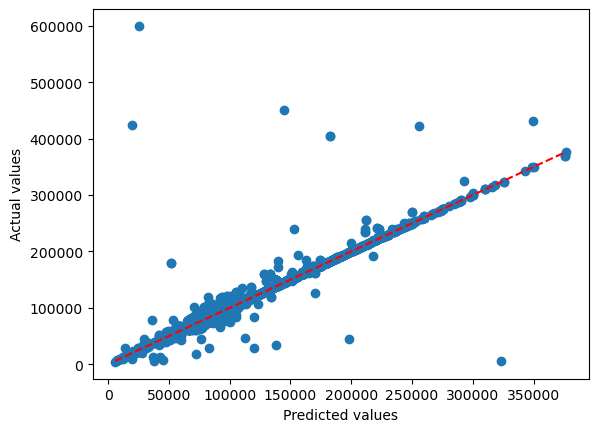

In [7]:
# Predict values
y_pred_bag = bagging.predict(X_test)

# plot predicted vs actual values
plt.scatter(y_pred_bag, y_test)
plt.plot([min(y_pred_bag), max(y_pred_bag)], [min(y_pred_bag), max(y_pred_bag)], 'r--')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')

In [8]:
# find the MSE
MSE_bag = mean_squared_error(y_test, y_pred_bag)
RMSE_bag = np.sqrt(MSE_bag)
print("Mean Squared Error: {:.2f}".format(MSE_bag))
print("Root Mean Squared Error: {:.2f}".format(RMSE_bag))

Mean Squared Error: 553084114.19
Root Mean Squared Error: 23517.74


In [9]:
# fit Random Forests model (Fewer Estimators)
bagging2 = RandomForestRegressor(max_features=X_train.shape[1]
                                       ,random_state = 2
                                       ,n_estimators=25)

bagging2.fit(X_train,y_train)

# Predict values
y_pred_bag = bagging2.predict(X_test)

# find the MSE
MSE_bag2 = mean_squared_error(y_test, y_pred_bag)
RMSE_bag2 = np.sqrt(MSE_bag2)
print("Mean Squared Error: {:.2f}".format(MSE_bag2))
print("Root Mean Squared Error: {:.2f}".format(RMSE_bag2))

Mean Squared Error: 568996573.91
Root Mean Squared Error: 23853.65


In [10]:
# create a dataframe of feature importances and their corresponding column names
importances_df_bag = pd.DataFrame({'Feature': X_train.columns, 'Importance': bagging2.feature_importances_})
importances_df_bag = importances_df_bag.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_df_bag)

        Feature  Importance
0        salary    0.960896
1     work_year    0.023740
2  remote_ratio    0.015364


In [11]:
# fit Random Forests model
df_rf = RandomForestRegressor(max_features=2
                                       ,random_state = 2)

df_rf.fit(X_train,y_train)

# Predict values
y_pred_rf = df_rf.predict(X_test)

# find the MSE
MSE_rf = mean_squared_error(y_test, y_pred_rf)
RMSE_rf = np.sqrt(MSE_rf)
print("Mean Squared Error: {:.2f}".format(MSE_rf))
print("Root Mean Squared Error: {:.2f}".format(RMSE_rf))

Mean Squared Error: 409674766.29
Root Mean Squared Error: 20240.42


In [12]:
# create a dataframe of feature importances and their corresponding column names
importances_df_rf = pd.DataFrame({'Feature': X_train.columns, 'Importance': df_rf.feature_importances_})
importances_df_rf = importances_df_rf.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_df_rf)

        Feature  Importance
0        salary    0.941598
1     work_year    0.042614
2  remote_ratio    0.015788


In [13]:
# fit Gradient Boosting model
boost_df = GradientBoostingRegressor(n_estimators=5000, max_depth=4
                                         , random_state=2)
boost_df.fit(X_train, y_train)

# create a dataframe of feature importances and their corresponding column names
importances_boost_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': boost_df.feature_importances_})
importances_boost_df = importances_boost_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_boost_df)

        Feature  Importance
0        salary    0.965858
1     work_year    0.027325
2  remote_ratio    0.006816


In [14]:
# Predict test
y_pred_boost = boost_df.predict(X_test)

# find the MSE
MSE_boost = mean_squared_error(y_test, y_pred_boost)
RMSE_boost = np.sqrt(MSE_boost)
print("Mean Squared Error: {:.2f}".format(MSE_boost))
print("Root Mean Squared Error: {:.2f}".format(RMSE_boost))

Mean Squared Error: 698808269.16
Root Mean Squared Error: 26434.98


\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


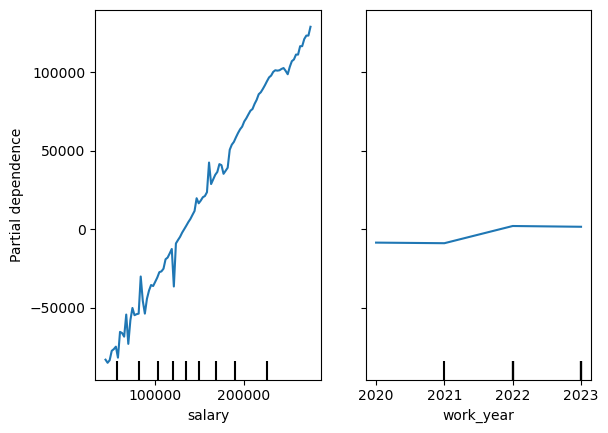

In [15]:
PartialDependenceDisplay.from_estimator(boost_df, X_train, ['salary', 'work_year']);

In [16]:
# fit the Gradient Boosting model
gboost_df = GradientBoostingRegressor(n_estimators=5000, max_depth=4
                                         , random_state=2
                                         , learning_rate=0.2)

gboost_df.fit(X_train, y_train)

# Predict test
y_pred_gboost = gboost_df.predict(X_test)

# find the MSE
MSE_gboost = mean_squared_error(y_test, y_pred_gboost)
RMSE_gboost = np.sqrt(MSE_gboost)
print("Mean Squared Error: {:.2f}".format(MSE_gboost))
print("Root Mean Squared Error: {:.2f}".format(RMSE_gboost))

Mean Squared Error: 682030098.87
Root Mean Squared Error: 26115.71


In [17]:
# create a dataframe of feature importances and their corresponding column names
importances_gboost_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': gboost_df.feature_importances_})
importances_gboost_df = importances_gboost_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_gboost_df)

        Feature  Importance
0        salary    0.964510
1     work_year    0.029462
2  remote_ratio    0.006028


# 5. Learn a new boosting method and apply it to your question. (XGBOOST + CATBOOST)

In [18]:
import catboost as cb
from catboost import CatBoostRegressor

In [19]:
# Initialize the CatBoostRegressor with RMSE as the loss function
catboost_df = CatBoostRegressor(iterations=50,depth=4,random_state=2,learning_rate=0.2,verbose=10)

catboost_df.fit(X_train,y_train)

0:	learn: 54813.5156860	total: 136ms	remaining: 6.64s
10:	learn: 25144.1381430	total: 140ms	remaining: 496ms
20:	learn: 22595.3389360	total: 144ms	remaining: 199ms
30:	learn: 21411.2743620	total: 149ms	remaining: 91.1ms
40:	learn: 20420.4030928	total: 153ms	remaining: 33.6ms
49:	learn: 19856.6854509	total: 156ms	remaining: 0us


CatBoostRegressor(depth=4, iterations=50, learning_rate=0.2, loss_function='RMSE', random_state=2, verbose=10)

In [20]:
# Predict test
y_pred_catboost = catboost_df.predict(X_test)

# find the MSE
MSE_cat = mean_squared_error(y_test, y_pred_catboost)
RMSE_cat = np.sqrt(MSE_cat)
print("Mean Squared Error: {:.2f}".format(MSE_cat))
print("Root Mean Squared Error: {:.2f}".format(RMSE_cat))

Mean Squared Error: 562738216.76
Root Mean Squared Error: 23722.10


In [28]:
# create a dataframe of feature importances and their corresponding column names
importances_catboost_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': catboost_df.feature_importances_})
importances_catboost_df = importances_catboost_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_catboost_df)

        Feature  Importance
0        salary   93.057110
1     work_year    5.513486
2  remote_ratio    1.429404


# Compare the model results (model performance, feature importance, etc.)

In [25]:
# Test Error

print("Bagging Mean Squared Error: {:.2f}".format(MSE_bag))
print("Bagging Root Mean Squared Error: {:.2f}".format(RMSE_bag))
print("Reduced Bagging Mean Squared Error: {:.2f}".format(MSE_bag2))
print("Reduced Bagging Root Mean Squared Error: {:.2f}".format(RMSE_bag2))
print("*Random Forest Mean Squared Error*: {:.2f}".format(MSE_rf))
print("*Random Forest Root Mean Squared Error*: {:.2f}".format(RMSE_rf))
print("Boosting Mean Squared Error: {:.2f}".format(MSE_boost))
print("Boosting Root Mean Squared Error: {:.2f}".format(RMSE_boost))
print("Gradient Boosting Mean Squared Error: {:.2f}".format(MSE_gboost))
print("Gradient Boosting Root Mean Squared Error: {:.2f}".format(RMSE_gboost))
print("Catboost Mean Squared Error: {:.2f}".format(MSE_cat))
print("Catboost Root Mean Squared Error: {:.2f}".format(RMSE_cat))

Bagging Mean Squared Error: 553084114.19
Bagging Root Mean Squared Error: 23517.74
Reduced Bagging Mean Squared Error: 568996573.91
Reduced Bagging Root Mean Squared Error: 23853.65
*Random Forest Mean Squared Error*: 409674766.29
*Random Forest Root Mean Squared Error*: 20240.42
Boosting Mean Squared Error: 698808269.16
Boosting Root Mean Squared Error: 26434.98
Gradient Boosting Mean Squared Error: 682030098.87
Gradient Boosting Root Mean Squared Error: 26115.71
Catboost Mean Squared Error: 562738216.76
Catboost Root Mean Squared Error: 23722.10


In [26]:
# Importance

print(importances_df_bagging)
print(importances_df_bag)
print(importances_df_rf)
print(importances_boost_df)
print(importances_gboost_df)
print(importances_catboost_df)

        Feature  Importance
0        salary    0.958376
1     work_year    0.024798
2  remote_ratio    0.016825
        Feature  Importance
0        salary    0.960896
1     work_year    0.023740
2  remote_ratio    0.015364
        Feature  Importance
0        salary    0.941598
1     work_year    0.042614
2  remote_ratio    0.015788
        Feature  Importance
0        salary    0.965858
1     work_year    0.027325
2  remote_ratio    0.006816
        Feature  Importance
0        salary    0.964510
1     work_year    0.029462
2  remote_ratio    0.006028
        Feature  Importance
0        salary   93.057110
1     work_year    5.513486
2  remote_ratio    1.429404


# 7. Interpret the results

Random Forest had the best model performance with a *Mean Squared Error* of 409674766.29 and a *Root Mean Squared Error* of 20240.42.

All of our models had an importance of 93%+ for salary, which makes sense since salary and salary_in_usd are highly correlated.